In [1]:
# 1 Importing required libraries 
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white, het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import reset_ramsey
from statsmodels.graphics.regressionplots import plot_partregress_grid
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import shapiro

In [2]:
# 2 Importing my CSV file into pandas dataframe and printing top five rows
df = pd.read_csv("Lamsal_housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,airconditioning,parking
0,13300000,7420,4,2,3,yes,2
1,12250000,8960,4,4,4,yes,3
2,12250000,9960,3,2,2,no,2
3,12215000,7500,4,2,2,yes,3
4,11410000,7420,4,1,2,yes,2


In [3]:
#Checking the data types for each variables
df.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
airconditioning    object
parking             int64
dtype: object

In [4]:
#Telling pandas the airconditioning coloumn should re replaced by 0 and 1
df.airconditioning.replace(('yes', 'no'), (1, 0), inplace=True)

In [5]:
#Again checking the data types for each variables
df.dtypes

price              int64
area               int64
bedrooms           int64
bathrooms          int64
stories            int64
airconditioning    int64
parking            int64
dtype: object

In [6]:
df.head()

,price,area,bedrooms,bathrooms,stories,airconditioning,parking
0,13300000,7420,4,2,3,1,2
1,12250000,8960,4,4,4,1,3
2,12250000,9960,3,2,2,0,2
3,12215000,7500,4,2,2,1,3
4,11410000,7420,4,1,2,1,2


In [7]:
#3 using pandas for calculating summary statistics
df.describe()

,price,area,bedrooms,bathrooms,stories,airconditioning,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.315596,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.465180,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,1.000000,3.000000


C:\Users\L E N O V O\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\L E N O V O\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\L E N O V O\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\L E N O V O\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values

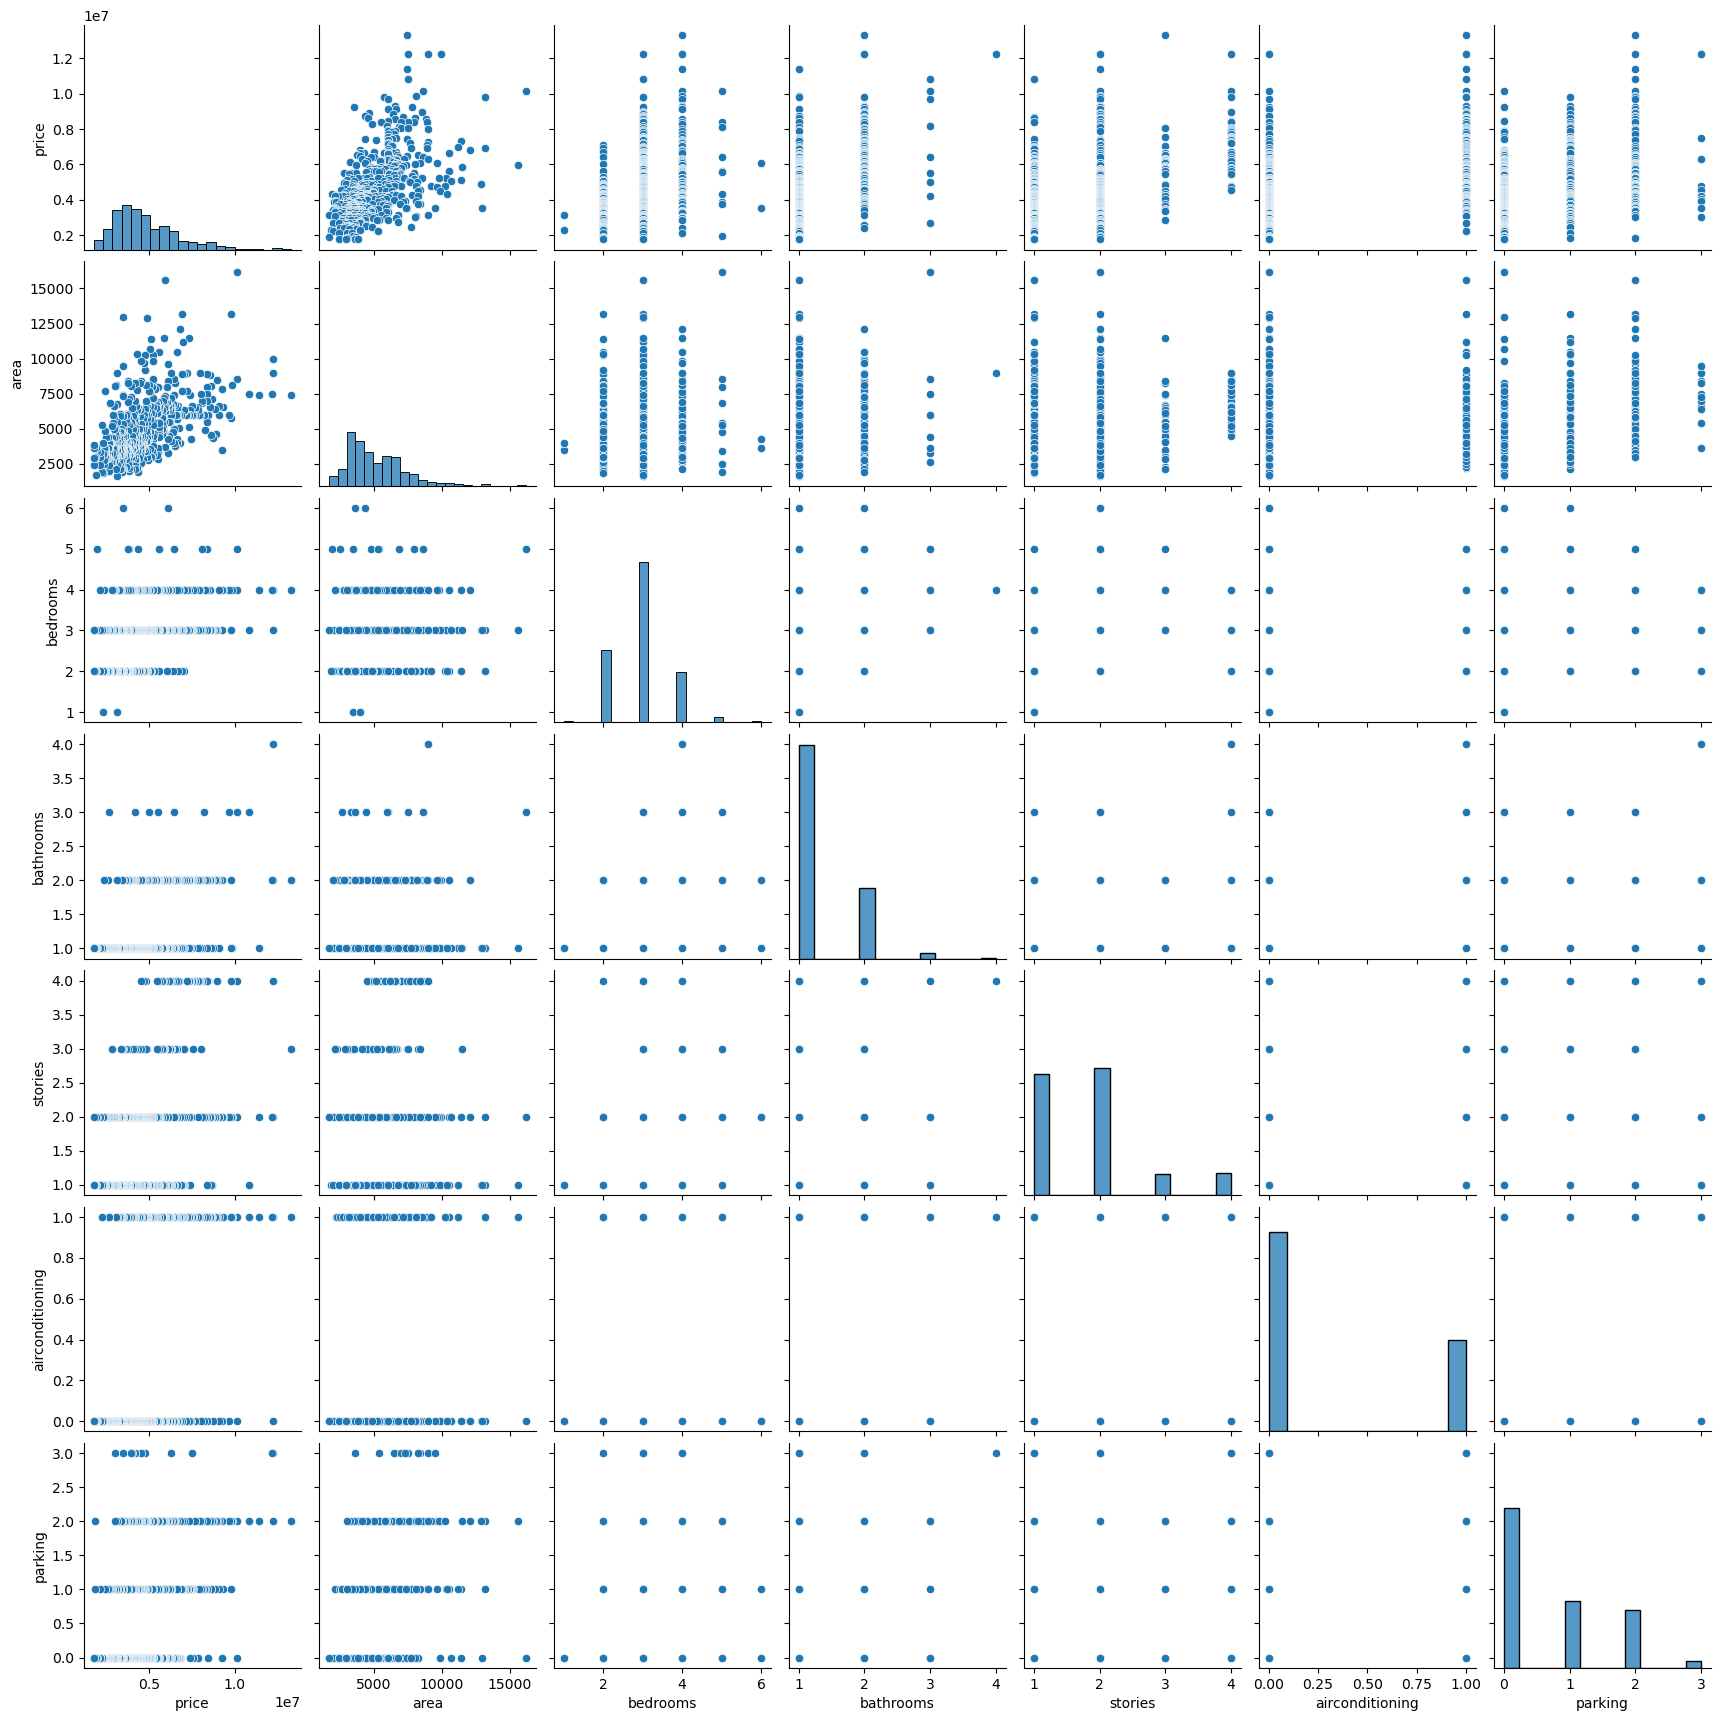

In [8]:
# 4 Using Seaborns pairplot function to produce graphic
sns.pairplot(df)

In [9]:
# 5 Splitting the dataframe into a dependent variable dataframe and an independent variables dataframe.
y= df['price']
xvars=['area', 'bedrooms','bathrooms', 'stories', 'airconditioning', 'parking']
X= df[xvars]

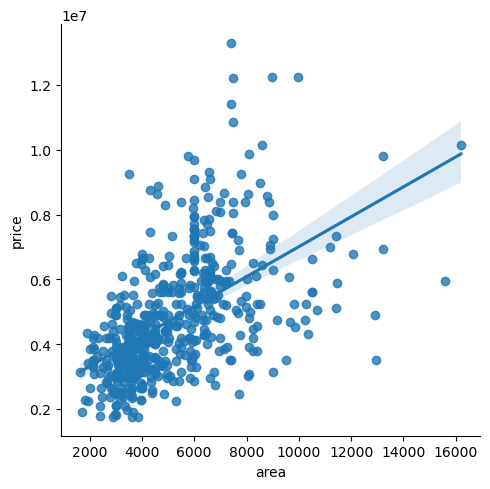

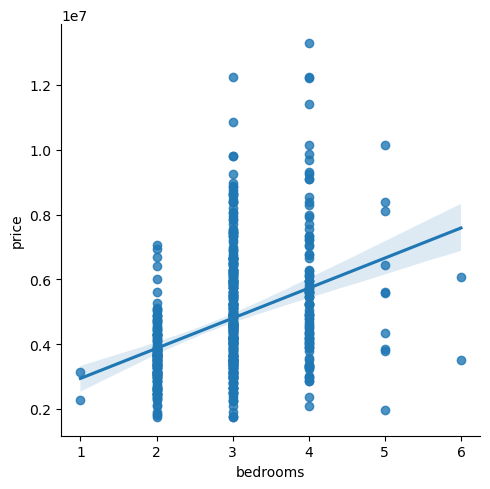

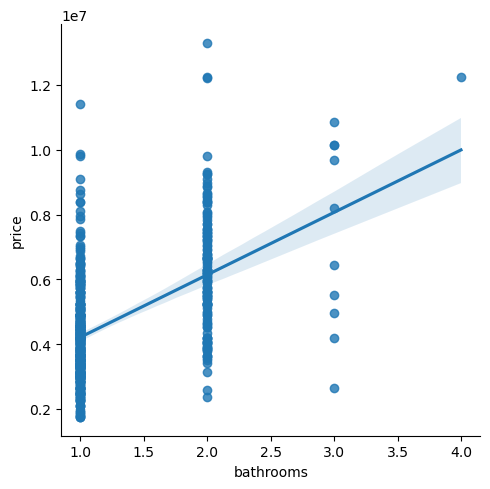

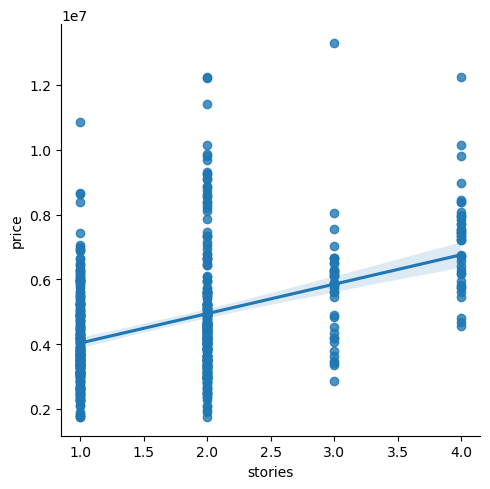

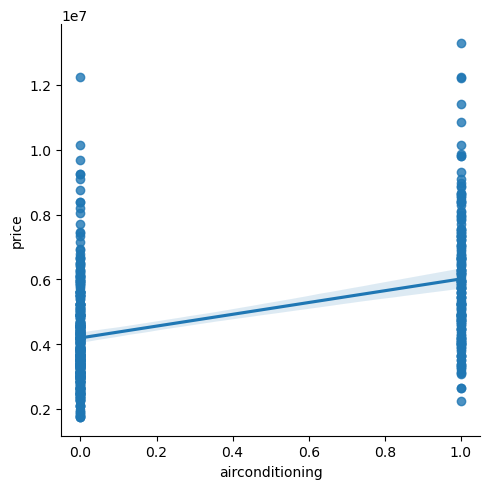

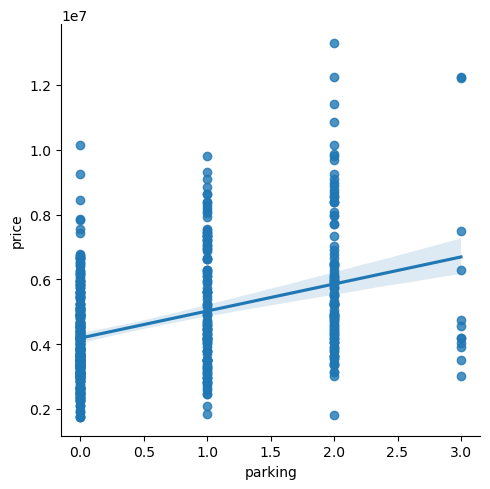

In [11]:
# plotting each independent variables against the dependent variables
for i in xvars:
    sns.lmplot(x=i, y='price', fit_reg=True, data=df)

In [12]:
#creating a constant
X=sm.add_constant(X)
X.head()

,const,area,bedrooms,bathrooms,stories,airconditioning,parking
0,1.0,7420,4,2,3,1,2
1,1.0,8960,4,4,4,1,3
2,1.0,9960,3,2,2,0,2
3,1.0,7500,4,2,2,1,3
4,1.0,7420,4,1,2,1,2


In [15]:
model1= sm.OLS.from_formula('price~ area + bedrooms + bathrooms', df)
results1=model1.fit()
results1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.487
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                     171.3
Date:                Fri, 10 May 2024   Prob (F-statistic):           4.80e-78
Time:                        18:44:34   Log-Likelihood:                -8461.6
No. Observations:                 545   AIC:                         1.693e+04
Df Residuals:                     541   BIC:                         1.695e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.732e+05   2.65e+05     -0.655      0.513   -6.93e+05    3.47e+05
area         378.7628     27.155     13.948      0.000     325.420     432.105
bedrooms    4.068e+05   8.45e+04      4.817      0.000    2.41e+05    5.73e+05
bathrooms   1.386e+06   1.25e+05     11.089      0.000    1.14e+06    1.63e+06
==============================================================================
Omnibus:                       70.408   Durbin-Watson:                   0.952
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              142.930
Skew:                           0.738   Prob(JB):                     9.19e-32
Kurtosis:                       5.029   Cond. No.                     2.64e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.64e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [16]:
#7 Comparing models and gathering regression statistics and values for model 1
rsquared1=results1.rsquared
adj_rsquared1=results1.rsquared_adj
aic1=results1.aic
bic1=results1.bic

In [17]:
model2=sm.OLS.from_formula('price~area + bedrooms + bathrooms + stories', df)
results2=model2.fit()
results2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.536
Model:                            OLS   Adj. R-squared:                  0.532
Method:                 Least Squares   F-statistic:                     155.7
Date:                Fri, 10 May 2024   Prob (F-statistic):           1.68e-88
Time:                        19:04:37   Log-Likelihood:                -8434.5
No. Observations:                 545   AIC:                         1.688e+04
Df Residuals:                     540   BIC:                         1.690e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -2.821e+05   2.52e+05     -1.118      0.264   -7.78e+05    2.14e+05
area         380.0244     25.864     14.693      0.000     329.219     430.830
bedrooms    1.983e+05   8.51e+04      2.330      0.020    3.11e+04    3.65e+05
bathrooms     1.2e+06   1.22e+05      9.871      0.000    9.61e+05    1.44e+06
stories     5.316e+05   7.08e+04      7.511      0.000    3.93e+05    6.71e+05
==============================================================================
Omnibus:                       94.932   Durbin-Watson:                   1.043
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              232.104
Skew:                           0.895   Prob(JB):                     3.97e-51
Kurtosis:                       5.649   Cond. No.                     2.64e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.64e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [18]:
# Gathering regression statistics and values for model 2
rsquared2=results2.rsquared
adj_rsquared2=results2.rsquared_adj
aic2=results2.aic
bic2=results2.bic

In [19]:
model3=sm.OLS.from_formula('price~area + stories + airconditioning + parking',df)
results3=model3.fit()
results3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.523
Model:                            OLS   Adj. R-squared:                  0.519
Method:                 Least Squares   F-statistic:                     147.9
Date:                Fri, 10 May 2024   Prob (F-statistic):           2.61e-85
Time:                        19:51:05   Log-Likelihood:                -8442.0
No. Observations:                 545   AIC:                         1.689e+04
Df Residuals:                     540   BIC:                         1.692e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        1.249e+06   1.79e+05      6.978      0.000    8.97e+05     1.6e+06
area              333.3809     27.847     11.972      0.000     278.679     388.083
stories          6.624e+05   6.71e+04      9.876      0.000    5.31e+05    7.94e+05
airconditioning  9.881e+05   1.28e+05      7.700      0.000    7.36e+05    1.24e+06
parking          4.228e+05   6.93e+04      6.105      0.000    2.87e+05    5.59e+05
==============================================================================
Omnibus:                       88.740   Durbin-Watson:                   0.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              194.299
Skew:                           0.879   Prob(JB):                     6.44e-43
Kurtosis:                       5.337   Cond. No.                     1.87e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.87e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [20]:
# Gathering regression statistics and values for model 3
rsquared3=results3.rsquared
adj_rsquared3=results3.rsquared_adj
aic3=results3.aic
bic3=results3.bic

In [22]:
# Comparing model1, model2, model3
models = ["model1","model2","model3"]
r_squared = [rsquared1, rsquared2, rsquared3]
adj_r_squared = [adj_rsquared1, adj_rsquared2, adj_rsquared3]
aic = [aic1, aic2, aic3]
bic = [bic1, bic2, bic3]

data = {
    "Model" : models,
    "R-squared": r_squared,
    "Adjusted R_squared": adj_r_squared,
    "AIC": aic,
    "BIC": bic
}
df_stats = pd.DataFrame(data)
print(df_stats)
    

    Model  R-squared  Adjusted R_squared           AIC           BIC
0  model1   0.487083            0.484239  16931.213150  16948.416293
1  model2   0.535596            0.532156  16879.062418  16900.566347
2  model3   0.522737            0.519202  16893.947439  16915.451368


In [23]:
# Conclusion: Here from the above table, we get the result that, model 2 has higher r_square and higher adjusted r_square with Lower AIC and BIC , therefore we can consider model 2 as the best model.


In [25]:
# Checking multicollinearity using variance inflation factor
vif= pd.DataFrame()
vif["Variable"]=X.columns
vif["VIF"]=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
print("Variance Inflation Factor (VIF) for Multicollinearity:") 
print(vif)

# Checking and printing if multicollinearity between independent variables exist excluding constant.
if (vif["VIF"]>5)[1:6].any():
    print("Multicollinearity detected!")
else:
    print("The independent variables are not correlated with each other.")

Variance Inflation Factor (VIF) for Multicollinearity:
          Variable        VIF
0            const  21.645539
1             area   1.201080
2         bedrooms   1.316604
3        bathrooms   1.256656
4          stories   1.332428
5  airconditioning   1.156117
6          parking   1.171659
The independent variables are not correlated with each other.


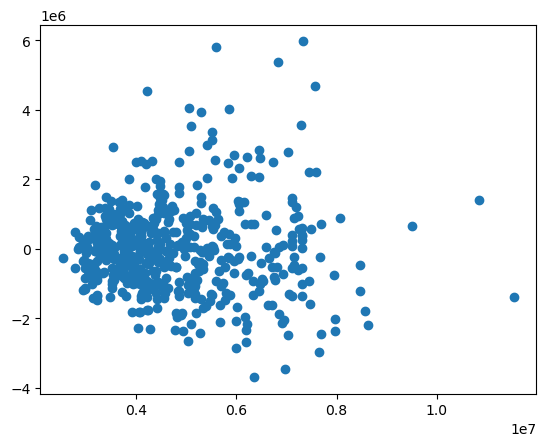

In [26]:
#9 Making scatterplot with the residuals on the y-axis 
yhat1=results2.fittedvalues
e1=results2.resid
plt.scatter(yhat1,e1)
plt.show()

3.99187070514084e-09


(array([  4.,  32., 103., 190., 142.,  43.,  19.,   6.,   3.,   3.]),
 array([-3696015.30822175, -2729015.56991147, -1762015.83160118,
         -795016.0932909 ,   171983.64501939,  1138983.38332968,
         2105983.12163996,  3072982.85995025,  4039982.59826054,
         5006982.33657082,  5973982.07488111]),
 <BarContainer object of 10 artists>)

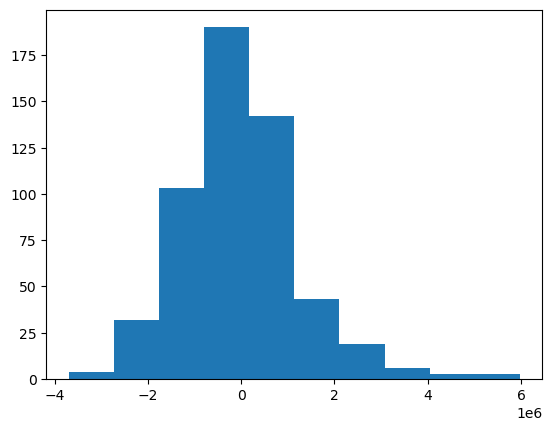

In [27]:
#checking they are normally distributed or not
print(e1.mean())
plt.hist(e1)

In [28]:
#Hence from the above result we found that the residuals are normally distributed.

In [29]:
#11 Using a statistical test to test for heteroskedasticity
bp_test=het_breuschpagan(e1,X)
print("Breusch Pagan Test P-Value")
print(bp_test[3])

if bp_test[3]<0.05:
    print("There is significant evidence of heteroskedasticity.")
else:
    print("There is not enough evidence to conclude that there is heteroskedasticity.")

Breusch Pagan Test P-Value
2.069895672311284e-13
There is significant evidence of heteroskedasticity.


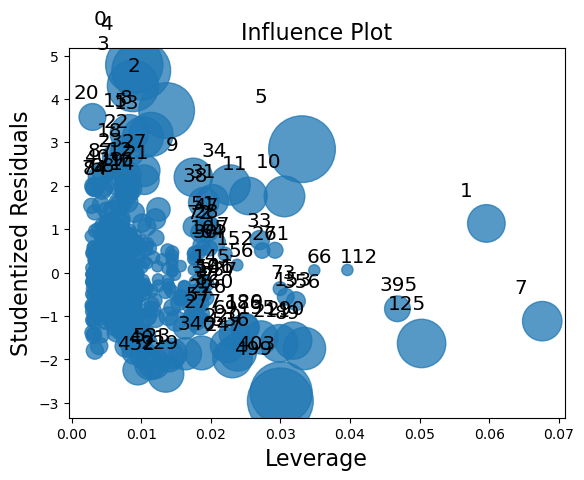

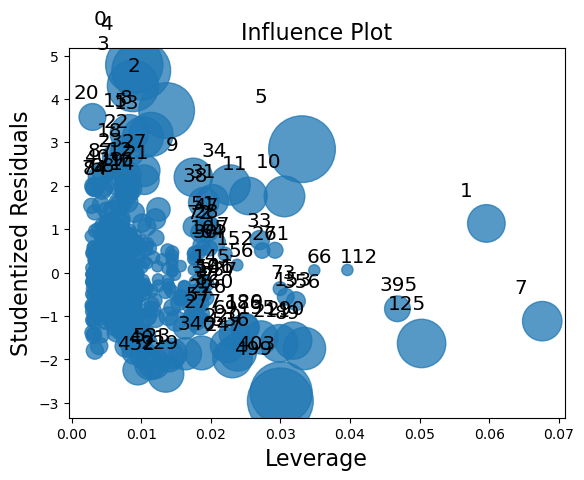

In [31]:
#12 Creating an influence plot to check for the outliers
sm.graphics.influence_plot(results2, criterioin="cooks")

In [32]:
# From both the figures above, it is clear that the majority of data points are away from the center
# Also, In above figure 1 we can see that there are some extreme outliers. Therefore, we can say that the data points are problematic.

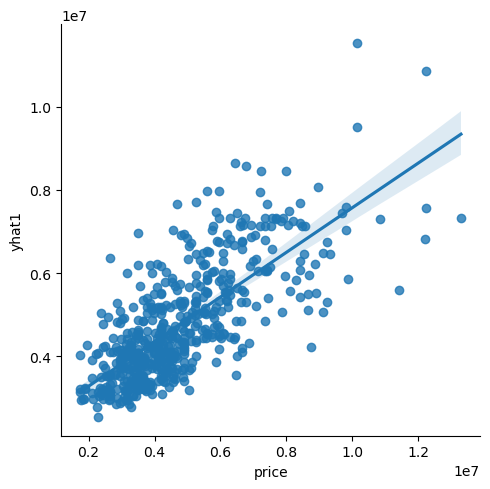

In [33]:
#13 Creating a scatterplot of Y vs Y-Hat by including trendline
# First, adding fitted values to original dataframe
df["yhat1"]=yhat1
sns.lmplot(x="price", y="yhat1", fit_reg=True, data=df)

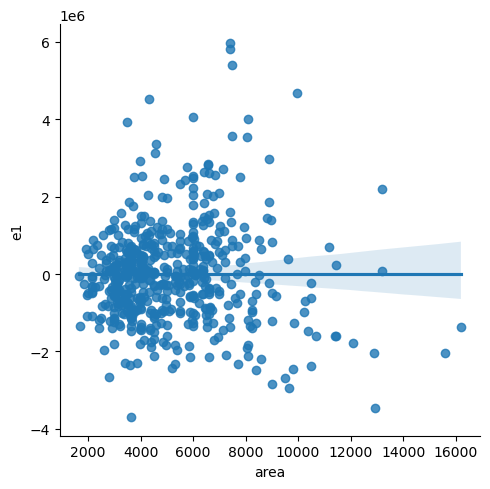

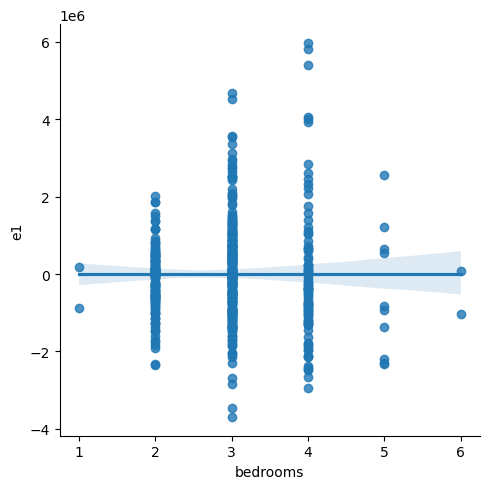

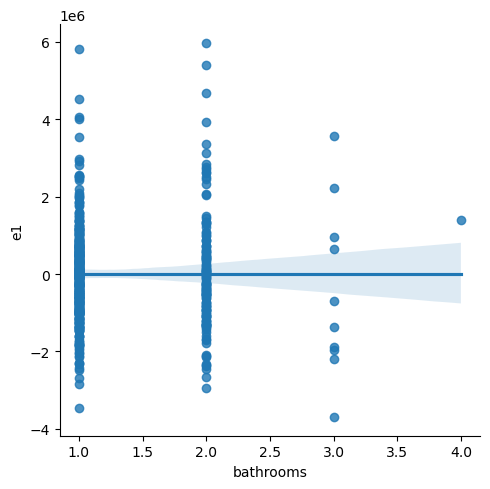

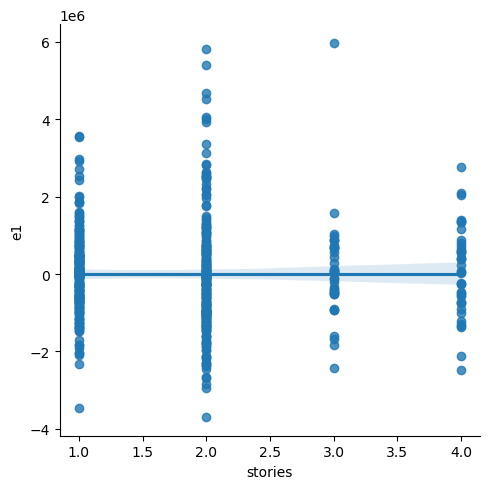

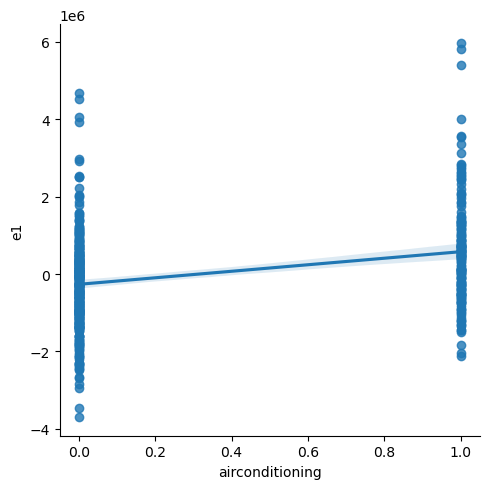

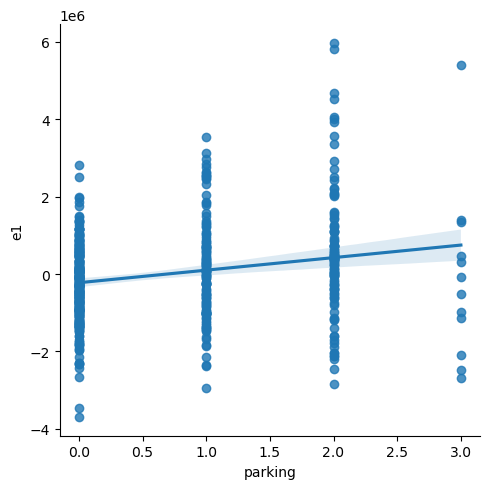

In [34]:
# 14 Creating a loop that loops through your x variable and plotting them against residuals
# And adding residual values to original data frames
df["e1"]=e1

for i in xvars:
    sns.lmplot(x=i, y="e1", fit_reg=True, data=df)


In [35]:
#Conclusion:
#From the above plottings, we found that apart from parking and airconditioning variables, other variables seems fine.
#The line of parking and air conditioning variables seems problamatic as its line is a bit diagonal.

In [38]:
#15 Creating a new dataframe with five hypothetical observations and using predict functions to calculate estimated y values

new_df=pd.DataFrame({
    "area":[8000, 9000, 10000, 11000, 12000],
    "bedrooms":[2, 3, 4, 5, 6],
    "bathrooms":[1, 2, 3, 4, 5],
    "stories":[1, 2, 3, 4, 5],
    "airconditioning":[2, 3, 4, 5, 6],
    "parking":[3, 4, 5, 6, 7],
})
new_df["Estimated_price"]=results2.predict(new_df)
new_df

,area,bedrooms,bathrooms,stories,airconditioning,parking,Estimated_price
0,8000,2,1,1,2,3,4.886471e+06
1,9000,3,2,2,3,4,7.196566e+06
2,10000,4,3,3,4,5,9.506661e+06
3,11000,5,4,4,5,6,1.181676e+07
4,12000,6,5,5,6,7,1.412685e+07
